#Some Questions from Practice, Assignment or Project have been grouped together as the task to be done was the same.

# Practice Q-1/Assignment Q-2 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
titanic = pd.read_csv('Titanic-Dataset.csv')
titanic_original = titanic.copy()

In [3]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
# First we will drop the irrelevant columns:

titanic = titanic.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'])
titanic

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


<Axes: xlabel='Survived', ylabel='count'>

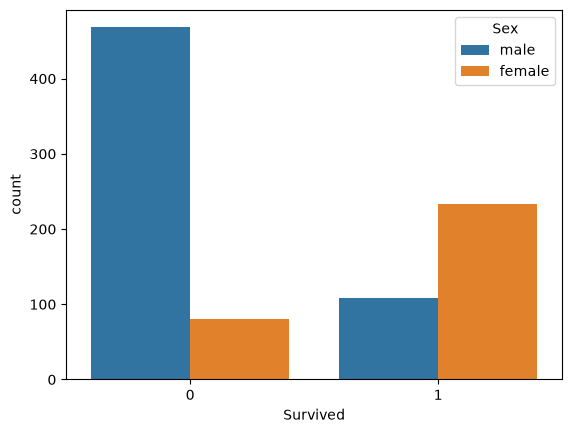

In [6]:
# Now we can do some preliminary analysis of the leftover features:

sns.countplot(x="Survived", hue="Sex", data = titanic)

# Sex and survival seem to be correlated as female survivors are more than male survivors.

<Axes: xlabel='Survived', ylabel='count'>

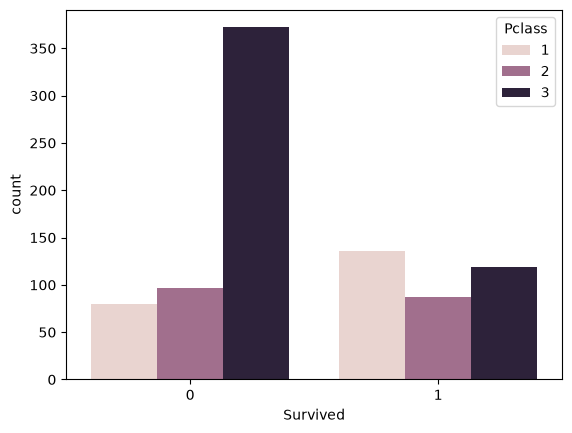

In [7]:
sns.countplot(x="Survived", hue="Pclass", data = titanic)

# Passenger Class and survival seem to be correlated as Passengers of Class 3 died the most.

<Axes: xlabel='Survived', ylabel='count'>

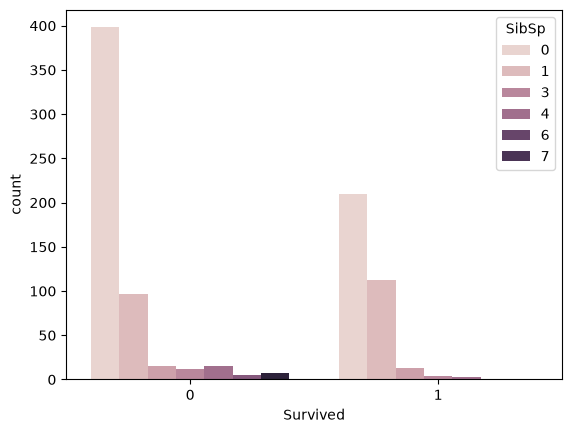

In [8]:
sns.countplot(x="Survived", hue="SibSp", data = titanic)


<Axes: xlabel='Survived', ylabel='count'>

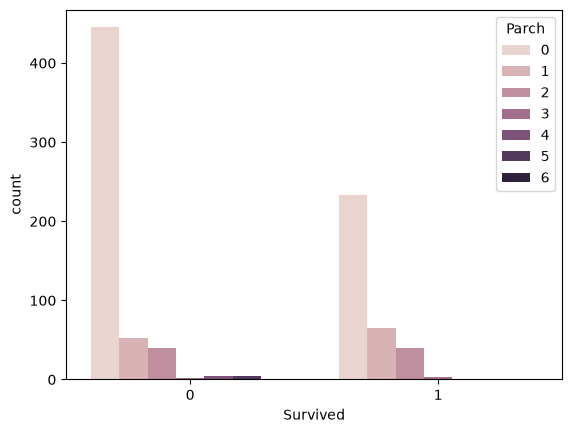

In [9]:
sns.countplot(x="Survived", hue="Parch", data = titanic)

# From plots of SibSp and Parch we can say that most passengers aboard seem to have smaller families as they occupy a large portion of survivors and casualties.
# Bigger Families were fewer but most of them seem to have not survived.
# Hence from the plot we can see some loose relationship between these features and survival.


<Axes: xlabel='Survived', ylabel='count'>

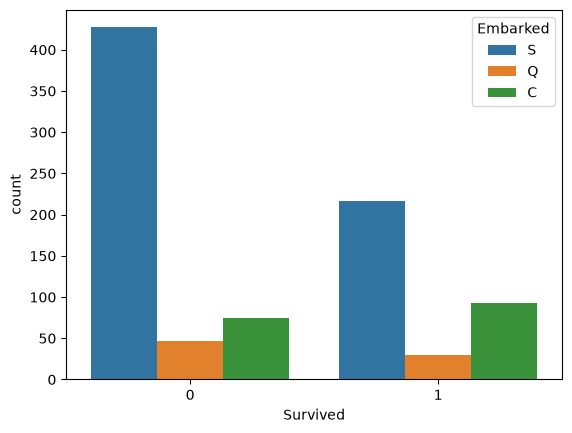

In [10]:
sns.countplot(x="Survived", hue="Embarked", data = titanic)

# Most passengers boarded at Southampton, hence they account for most survivors & casualties.
# But, Cherbourg is the only port whose no. of survivors are more than its casualties.
# Hence, some correlation with survival can be seen.

<Axes: xlabel='Survived', ylabel='Age'>

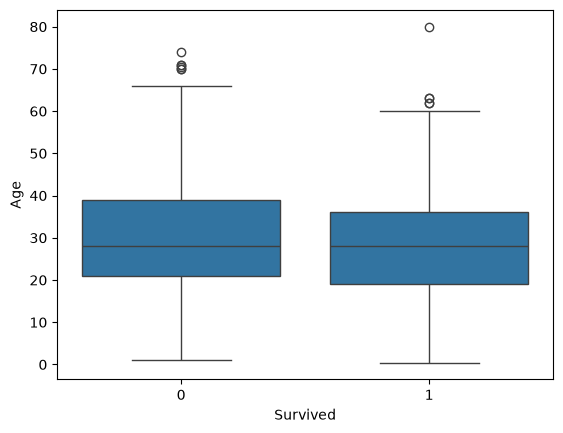

In [11]:
sns.boxplot(x= 'Survived', y= 'Age', data= titanic)


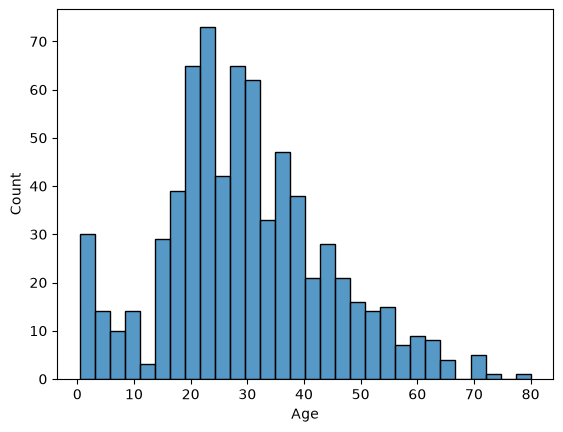

In [12]:
sns.histplot(data= titanic, x='Age', bins=30)
plt.show()

# Most passengers were Adults between the ages of 20 and 30 hence they represent the age group of most of the survivors and casualties.
# Elderly individuals were fewer, as shown by the outliers. Some of them were survived while others did not.

In [13]:
# Pre processing of Data:

titanic.isnull().sum()

titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())

titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

print(titanic.isnull().sum())

titanic['Sex'] = titanic['Sex'].map({'male': 0, 'female': 1}) 
titanic = pd.get_dummies(titanic, columns = ['Embarked'], drop_first= True, dtype=int)

print(titanic)



Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64
     Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  \
0           0       3    0  22.0      1      0   7.2500           0   
1           1       1    1  38.0      1      0  71.2833           0   
2           1       3    1  26.0      0      0   7.9250           0   
3           1       1    1  35.0      1      0  53.1000           0   
4           0       3    0  35.0      0      0   8.0500           0   
..        ...     ...  ...   ...    ...    ...      ...         ...   
886         0       2    0  27.0      0      0  13.0000           0   
887         1       1    1  19.0      0      0  30.0000           0   
888         0       3    1  28.0      1      2  23.4500           0   
889         1       1    0  26.0      0      0  30.0000           0   
890         0       3    0  32.0      0      0   7.7500           1   

     Embarked_S  
0   

In [14]:
# Training the Model:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = LogisticRegression()

X = titanic.drop(['Survived'], axis = 1)
y = titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 1 )

from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)


#Practice Question 2:

In [15]:
print (f"Accuracy is: {accuracy_score(y_test, y_pred):.2f}") 

print (f"Confusion Matrix is:\n{confusion_matrix(y_test,y_pred)}")


Accuracy is: 0.78
Confusion Matrix is:
[[130  23]
 [ 37  78]]


#Practice Question 3:

In [16]:
#Decision Tree Classifier:

titanic_tree = titanic.copy()

In [17]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state = 1)
X_tree = titanic_tree.drop('Survived', axis = 1)
y_tree = titanic_tree['Survived']

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(X_tree, y_tree, test_size = 0.3, random_state = 1)

tree_model.fit(X_tree_train, y_tree_train)

y_tree_pred = tree_model.predict(X_tree_test)

print (f"Accuracy is: {accuracy_score(y_tree_test, y_tree_pred):.2f}")

print (f"Confusion Matrix is:\n{confusion_matrix(y_tree_test,y_tree_pred)}")

Accuracy is: 0.76
Confusion Matrix is:
[[128  25]
 [ 39  76]]


In [18]:
# KNN Classifier:

titanic_knn = titanic.copy()

X_knn = titanic_knn.drop('Survived', axis = 1)
y_knn = titanic_knn['Survived']

X_knn_train, X_knn_test, y_knn_train, y_knn_test = train_test_split(X_knn, y_knn, test_size = 0.3, random_state = 1)

knn_sc= StandardScaler()
X_knn_train = knn_sc.fit_transform(X_knn_train)
X_knn_test = knn_sc.transform(X_knn_test)

from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

knn.fit(X_knn_train, y_knn_train)

y_knn_pred = knn.predict(X_knn_test)

print (f"Accuracy is: {accuracy_score(y_knn_test, y_knn_pred):.2f}")

print (f"Confusion Matrix is:\n{confusion_matrix(y_knn_test,y_knn_pred)}")



Accuracy is: 0.78
Confusion Matrix is:
[[137  16]
 [ 43  72]]


In [19]:
print (f'Accuracy of Decision Tree Classifier is: {accuracy_score(y_tree_test, y_tree_pred):.2f}\nAccuracy of KNN CLassifier is: {accuracy_score(y_knn_test, y_knn_pred):.2f}')

Accuracy of Decision Tree Classifier is: 0.76
Accuracy of KNN CLassifier is: 0.78


#Practice Question 4:

In [20]:
print(f"Train accuracy:{tree_model.score(X_tree_train, y_tree_train):.2f}")
print(f"Test accuracy:{tree_model.score(X_tree_test, y_tree_test):.2f}")

# This is the accuracy when the DecisionTree is left unconstrained.

Train accuracy:0.99
Test accuracy:0.76


In [21]:
# Tuning the max depth of the DecisionTree Classifier:

tree_model_tuned = DecisionTreeClassifier(random_state = 1, max_depth = 4)
tree_model_tuned.fit(X_tree_train, y_tree_train)

print(f"Train accuracy:{tree_model_tuned.score(X_tree_train, y_tree_train):.2f}")
print(f"Test accuracy:{tree_model_tuned.score(X_tree_test, y_tree_test):.2f}")

# Now we can compare the accuracy at different max depths and see which of them is best.


Train accuracy:0.86
Test accuracy:0.78


In [22]:
for depth in [2, 3, 4, 5 , 6, None]:
    tree_model_tuned = DecisionTreeClassifier(random_state = 1, max_depth =depth)
    tree_model_tuned.fit(X_tree_train, y_tree_train)
    print(f"Max_depth:{depth}\n Train accuracy:{tree_model_tuned.score(X_tree_train, y_tree_train):.2f}\nTest accuracy:{tree_model_tuned.score(X_tree_test, y_tree_test):.2f}\n")
    

Max_depth:2
 Train accuracy:0.82
Test accuracy:0.74

Max_depth:3
 Train accuracy:0.86
Test accuracy:0.77

Max_depth:4
 Train accuracy:0.86
Test accuracy:0.78

Max_depth:5
 Train accuracy:0.88
Test accuracy:0.78

Max_depth:6
 Train accuracy:0.91
Test accuracy:0.79

Max_depth:None
 Train accuracy:0.99
Test accuracy:0.76



In [23]:
# General trend shows that as depth increases, accuracy increases but dips back down when tree left unconstrained.
# Out of this limited set of depth values, Max depth of 4 seems to be the best fit for this data.
# This is because it provides a 0.78 accuracy score with least train-test accuracy gap.
# As depth increases to 5,6 test accuracy has negligible impact but the train-test gap widens.
# This shows that the model has begun overfitting and memorising training set, thus it is able to significantly improve training accuracy but not test accuracy.


# Assignment Q-1 / Mini- project 2:

In [24]:
import pandas as pd
house = pd.read_csv('Housing.csv')
house_original = house.copy()
house.head()



,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [25]:
house.info()
house.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [26]:
for col in house.select_dtypes(include='str').columns:
    print(house[col].value_counts())
    print()

mainroad
yes    468
no      77
Name: count, dtype: int64

guestroom
no     448
yes     97
Name: count, dtype: int64

basement
no     354
yes    191
Name: count, dtype: int64

hotwaterheating
no     520
yes     25
Name: count, dtype: int64

airconditioning
no     373
yes    172
Name: count, dtype: int64

prefarea
no     417
yes    128
Name: count, dtype: int64

furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140
Name: count, dtype: int64



In [27]:
categorical_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
house[categorical_cols] = house[categorical_cols].replace({'yes':1, 'no':0})
house = pd.get_dummies(house, columns=['furnishingstatus'], drop_first= True, dtype = 'int' )


In [28]:
house

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,1,0,1,0,0,2,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,1,0,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [29]:
# Training the model:

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

linear = LinearRegression()

X_lin = house.drop(columns = ['price'])
y_lin = house['price']

X_lin_train, X_lin_test, y_lin_train, y_lin_test = train_test_split(X_lin, y_lin, test_size = 0.2, random_state = 42)

linear.fit(X_lin_train, y_lin_train)
y_lin_pred = linear.predict(X_lin_test)

r2_score = r2_score(y_lin_test, y_lin_pred)

print(f"R^2 score is: {r2_score:.2f}\n")




R^2 score is: 0.65



In [30]:
# R^2 score is 0.65 which means that 65% of variance in house prices can be explained by the model.

In [31]:
X_lin.columns.tolist()

['area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

In [32]:
input_a = [[9000, 3, 3, 1, 0, 1, 1, 1, 2, 1, 0, 0]]
input_a_df = pd.DataFrame([[9000, 3, 2, 3, 1, 0, 1, 1, 1, 2, 1, 0, 0]], 
                        columns = ['area',
 'bedrooms','bathrooms', 'stories','mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished'])

price_a = linear.predict(input_a_df)

print(f" Price of House - a is : {price_a}")


 Price of House - a is : [9339229.19744829]


In [33]:
input_b = [[8000, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0]]
input_b_df = pd.DataFrame([[8000, 2, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0]], 
                        columns = ['area',
 'bedrooms','bathrooms', 'stories','mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished'])

price_b = linear.predict(input_b_df)

print(f" Price of House - b is : {price_b}")


 Price of House - b is : [7533646.73986293]


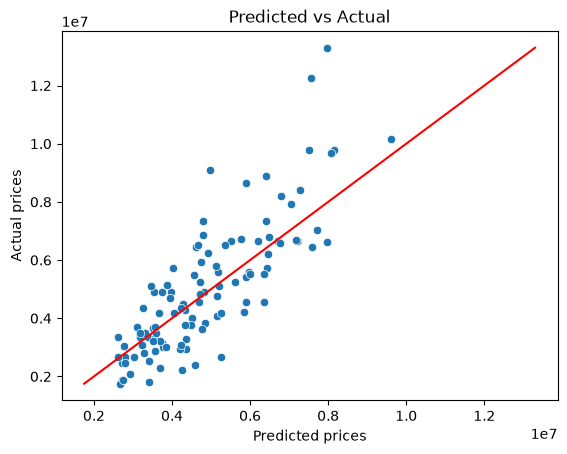

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x= y_lin_pred, y= y_lin_test)
plt.xlabel('Predicted prices')
plt.ylabel('Actual prices')
plt.title("Predicted vs Actual")

min_val = min(y_lin_pred.min(), y_lin_test.min())
max_val = max(y_lin_pred.max(), y_lin_test.max())
plt.plot([min_val,max_val], [min_val,max_val], color = 'red')
